# 04 - Baseline ML DOGE/USDT

## Objetivo del notebook

Construir un baseline de machine learning para predecir la dirección futura del precio de DOGE/USDT utilizando el dataset enriquecido en la fase de feature engineering.

El notebook evalúa si las variables generadas contienen una señal predictiva mínima antes de pasar a una fase más realista de backtesting. Para ello se comparan varios modelos supervisados clásicos sobre un split temporal, evitando data leakage y manteniendo una evaluación coherente con la naturaleza secuencial del problema.El objetivo no es demostrar rentabilidad financiera, sino establecer una referencia técnica inicial:

- Validar el pipeline de datos procesados
- Comprobar que las variables futuras quedan excluidas del entrenamiento
- Comparar modelos supervisados sencillos y robustos
- Identificar si existe una señal predictiva mínima sobre `up_1`
- Seleccionar un modelo base para la fase posterior de backtesting

Este notebook representa la transición entre el análisis exploratorio del dataset y la evaluación práctica de estrategias de trading.


In [1]:
# ============================================================
# Imports y carga del dataset
# Se carga el dataset enriquecido generado durante el proceso de feature engineering.
# A partir de este punto, el objetivo ya no es crear variables, sino comprobar si dichas variables contienen suficiente información como para predecir el comportamiento futuro del mercado.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")


df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(712257, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-07 11:50:00,0.003496,0.003503,0.003492,0.003492,145316.0,2019-07-07 11:54:59.999,508.053883,14,37501.0,...,0.402795,0.003365,0.00368,0.036312,0.053837,0.0,0.0,30.0,0.0,30.0
1,2019-07-07 11:55:00,0.003494,0.003500,0.003492,0.003500,1727089.0,2019-07-07 11:59:59.999,6040.557436,21,1017415.0,...,0.429479,0.003365,0.00368,0.038624,0.051308,0.0,0.0,30.0,0.0,30.0
2,2019-07-07 12:00:00,0.003497,0.003505,0.003491,0.003505,2644825.0,2019-07-07 12:04:59.999,9268.834500,26,811589.0,...,0.443456,0.003365,0.00368,0.039831,0.049989,0.0,0.0,30.0,0.0,30.0
3,2019-07-07 12:05:00,0.003505,0.003505,0.003487,0.003498,1335881.0,2019-07-07 12:09:59.999,4672.287479,35,1267575.0,...,0.422490,0.003365,0.00368,0.038020,0.051970,0.0,0.0,30.0,0.0,30.0
4,2019-07-07 12:10:00,0.003498,0.003516,0.003498,0.003505,5442392.0,2019-07-07 12:14:59.999,19046.081219,64,5027347.0,...,0.444091,0.003365,0.00368,0.039886,0.049929,0.0,0.0,30.0,0.0,30.0


In [2]:
# ============================================================
# Selección de features y target
# El dataset incluye tanto indicadores técnicos clásicos como nuevas variables estructurales relacionadas con soportes y resistencias.
# Estas features intentan formalizar conceptos tradicionales del análisis técnico utilizando únicamente información histórica disponible en cada instante temporal.
#
# Muy importante:
# Todas las columnas derivadas del futuro deben excluirse explícitamente del entrenamiento.
# Columnas como future_close_x o future_return_x solo existen para construir targets o evaluar retornos posteriores.
# Si se incluyen como features, el modelo estaría viendo información futura y las métricas quedarían completamente contaminadas por data leakage.
# ============================================================

TARGET = "up_1"

# ============================================================
# Explicit columns to exclude
# ============================================================

exclude_cols = [
    "open_time",
    "close_time",

    # Future prices used only to build labels
    "future_close_1",
    "future_close_3",
    "future_close_6",
    "future_close_12",

    # Future returns used only to build labels / evaluate future movement
    "future_return_1",
    "future_return_3",
    "future_return_6",
    "future_return_12",

    # Binary labels
    "up_1",
    "up_3",
    "up_6",
    "up_12"
]

# ============================================================
# Defensive leakage filter
# Exclude any remaining column that clearly refers to future information or labels.
# This protects the notebook if new horizons are added later.
# ============================================================

leakage_patterns = (
    "future_",
    "target_",
    "label_",
    "up_"
)

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
    and not col.startswith(leakage_patterns)
]

X = df[feature_cols]
y = df[TARGET]

print("Number of features:", len(feature_cols))
print(feature_cols)

# ============================================================
# Leakage sanity check
# ============================================================

leakage_cols_found = [
    col for col in X.columns
    if col.startswith(leakage_patterns)
]

print("Potential leakage columns in X:", leakage_cols_found)

Number of features: 40
['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'return_prev_1', 'log_return_prev_1', 'sma_20', 'ema_10', 'ema_50', 'ema_200', 'ema10_ema50_ratio', 'ema50_ema200_ratio', 'sma20_ema50_ratio', 'volatility_1h', 'zscore_close_1h', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_percent', 'atr_14', 'price_position_in_recent_range', 'recent_support', 'recent_resistance', 'dist_to_nearest_support', 'dist_to_nearest_resistance', 'near_support', 'near_resistance', 'support_strength', 'resistance_strength', 'touch_count_near_level']
Potential leakage columns in X: []


In [3]:
# ============================================================
# Split temporal train/test
# Al ser una serie temporal hacemos un split temporal y no aleatorio.
# Mezclar filas aleatoriamente permitiría entrenar con datos “del futuro” y evaluar con datos “del pasado”, algo completamente irreal en un entorno financiero.
# El split temporal intenta simular una situación más cercana al mundo real:
# El modelo aprende del pasado y predice el futuro.
# ============================================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (569805, 40)
Test shape: (142452, 40)


## Conclusiones - Split temporal y prevención de leakage

El dataset se divide respetando el orden cronológico, con 569.805 registros para entrenamiento y 142.452 registros para test.

Este punto es crítico porque el problema no consiste en clasificar observaciones independientes, sino en predecir eventos futuros a partir de información pasada. Un split aleatorio podría inflar las métricas al mezclar patrones temporales posteriores dentro del entrenamiento.

La comprobación de columnas también confirma que no se han incluido variables futuras ni targets alternativos dentro de `X`. El modelo trabaja con 40 features explicativas, excluyendo explícitamente columnas temporales, precios futuros, retornos futuros y targets derivados.

- El entrenamiento utiliza únicamente información histórica
- La evaluación se realiza sobre un tramo temporal posterior
- Las columnas `future_*` y `up_*` quedan excluidas de las features
- El resultado es una evaluación más dura, pero más honesta


In [4]:
# ============================================================
# Naive baseline
# El baseline ingenuo sirve como referencia mínima. Si un modelo de machine learning no mejora claramente esta estrategia, entonces no está aportando valor predictivo suficiente.
# En este caso, el baseline representa una regla muy simple: predecir siempre la clase mayoritaria observada en el conjunto de entrenamiento.
# ============================================================

majority_class = y_train.mode()[0]

naive_preds = np.full(shape=len(y_test), fill_value=majority_class)

naive_accuracy = accuracy_score(y_test, naive_preds)
naive_precision = precision_score(y_test, naive_preds, zero_division=0)
naive_recall = recall_score(y_test, naive_preds, zero_division=0)
naive_f1 = f1_score(y_test, naive_preds, zero_division=0)

print("Naive Baseline Metrics")
print("Accuracy :", naive_accuracy)
print("Precision:", naive_precision)
print("Recall   :", naive_recall)
print("F1-score :", naive_f1)

Naive Baseline Metrics
Accuracy : 0.5104456237890658
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


## Conclusiones - Naive baseline

El baseline ingenuo obtiene una accuracy de 0,5104, pero precision, recall y F1-score iguales a 0 para la clase positiva.

La lectura importante es que el 51 % de accuracy no representa capacidad predictiva real. El modelo simplemente predice siempre la clase mayoritaria observada en el conjunto de entrenamiento y, por tanto, nunca identifica movimientos alcistas.

Este resultado sirve como suelo mínimo de comparación:

- Cualquier modelo útil debe superar este baseline sin ignorar la clase positiva
- La accuracy aislada no basta para evaluar el problema
- El F1-score resulta más informativo para comparar capacidad real de detección


In [5]:
# ============================================================
# Logistic Regression Baseline
# Logistic Regression funciona como primer modelo supervisado interpretable. Al ser un modelo lineal, permite comprobar si existe una relación simple entre las features técnicas y la dirección futura del precio.
# En un problema financiero de muy corto plazo, resultados cercanos al azar no son necesariamente un fallo del código, pueden indicar que la señal predictiva es débil frente al ruido del mercado.
# ============================================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.52      0.70      0.60     72714
           1       0.51      0.33      0.40     69738

    accuracy                           0.52    142452
   macro avg       0.52      0.51      0.50    142452
weighted avg       0.52      0.52      0.50    142452



## Conclusiones - Logistic Regression

Logistic Regression mejora claramente al baseline ingenuo en F1-score, aunque la mejora en accuracy es pequeña.

El modelo obtiene una accuracy de 0,5184 y un F1-score de 0,3997 para la clase positiva. La precision se mantiene en 0,5126, mientras que el recall alcanza 0,3276.

La interpretación es prudente: el modelo no predice con gran fuerza, pero sí deja de comportarse como una regla trivial. Detecta una parte de los movimientos alcistas sin disparar por completo los falsos positivos, aunque todavía queda lejos de una capacidad predictiva robusta.

- Hay una señal lineal mínima en las features
- La mejora frente al baseline existe, pero es limitada
- El resultado todavía está demasiado cerca del azar para asumir utilidad financiera directa


In [6]:
# ============================================================
# Random Forest Baseline
# Random Forest permite capturar relaciones no lineales entre variables técnicas. Esto puede ser útil cuando la señal no se expresa como una relación lineal simple.
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.52      0.76      0.62     72714
           1       0.52      0.27      0.35     69738

    accuracy                           0.52    142452
   macro avg       0.52      0.51      0.49    142452
weighted avg       0.52      0.52      0.49    142452



## Conclusiones - Random Forest

Random Forest obtiene la mayor accuracy del notebook, 0,5189, pero reduce bastante el recall de la clase positiva.

El modelo alcanza una precision de 0,5167, pero solo detecta el 26,79 % de los movimientos alcistas reales. Esto indica un comportamiento más conservador que Logistic Regression: acierta algo más cuando predice subida, pero predice menos subidas.

El resultado no confirma que añadir no linealidad mejore automáticamente el problema. En este caso, el modelo parece ganar algo de precision a costa de perder cobertura sobre la clase positiva.

- Mejor accuracy global del conjunto comparado
- Menor recall para movimientos alcistas
- Comportamiento más conservador
- Posible sensibilidad a ruido o redundancia entre variables


Top 20 most important features
                           feature  importance
19                 zscore_close_1h    0.084573
28                      bb_percent    0.074128
10               log_return_prev_1    0.065926
9                    return_prev_1    0.065281
6                 number_of_trades    0.053425
4                           volume    0.053125
5               quote_asset_volume    0.050224
29                          atr_14    0.036899
20                          rsi_14    0.036401
8     taker_buy_quote_asset_volume    0.029761
7      taker_buy_base_asset_volume    0.027778
23                       macd_hist    0.025843
21                            macd    0.023500
15               ema10_ema50_ratio    0.022722
34      dist_to_nearest_resistance    0.020411
25                        bb_upper    0.018894
27                        bb_width    0.018300
24                          bb_mid    0.017599
30  price_position_in_recent_range    0.017422
22                     macd_s

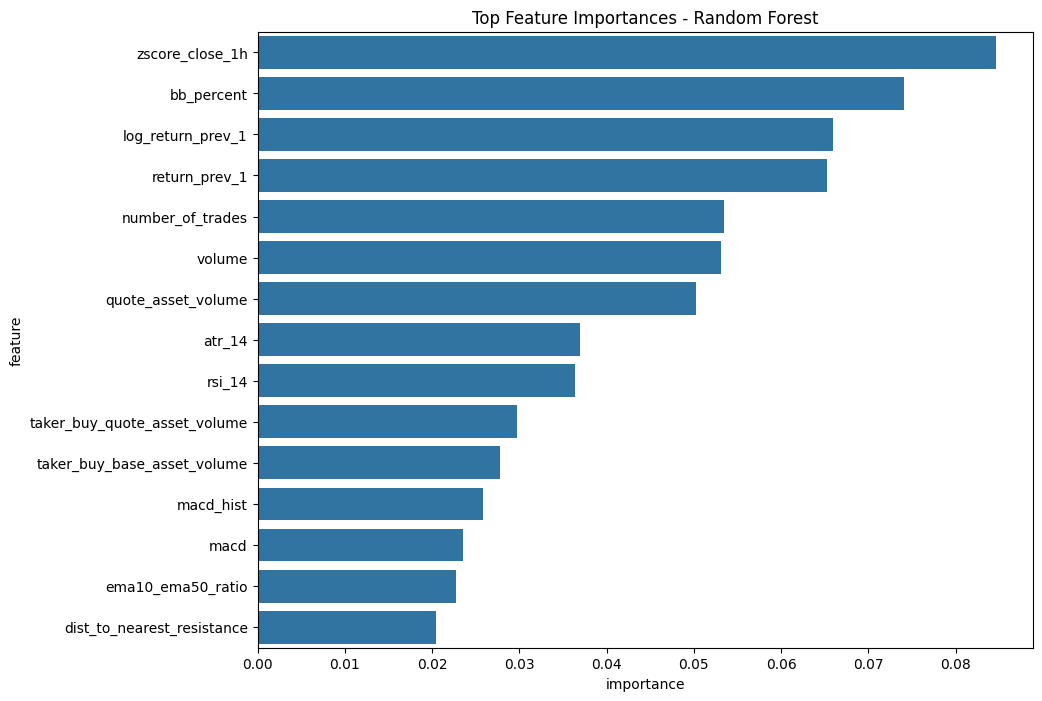

In [7]:
# ============================================================
# Feature importance
# La importancia de variables ayuda a interpretar qué indicadores influyen más en las predicciones del Random Forest.
# ============================================================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 20 most important features")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances - Random Forest")
plt.show()

## Conclusiones - Importancia de variables

Las variables con mayor peso en Random Forest siguen siendo principalmente indicadores de momentum, volatilidad, volumen y posición reciente del precio.

Destacan especialmente `zscore_close_1h`, `bb_percent`, `log_return_prev_1`, `return_prev_1`, `number_of_trades`, `volume`, `quote_asset_volume` y `atr_14`.

Las variables estructurales añadidas en la fase de feature engineering también aparecen, aunque con menor peso relativo. En particular, `dist_to_nearest_resistance` entra en el top 20, lo que sugiere que la distancia a niveles técnicos sí aporta información al modelo, pero no domina la decisión.

La lectura útil para el proyecto es que las nuevas features no son irrelevantes, pero tampoco sustituyen a las señales clásicas de precio, volumen y volatilidad.

- Las features clásicas siguen concentrando la mayor parte de la importancia
- Algunas variables de soporte/resistencia aportan señal secundaria
- Conviene validar estas variables en backtesting antes de asumir que mejoran la estrategia


In [8]:
# ============================================================
# XGBoost
# XGBoost suele considerarse uno de los modelos baseline más potentes para datos tabulares y competiciones de machine learning.
# Combina múltiples árboles de decisión de forma secuencial, corrigiendo progresivamente los errores de los árboles anteriores.
# En datasets financieros suele funcionar especialmente bien cuando existen relaciones complejas y señales débiles mezcladas con mucho ruido.
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.52      0.63      0.57     72714
           1       0.51      0.40      0.45     69738

    accuracy                           0.52    142452
   macro avg       0.52      0.51      0.51    142452
weighted avg       0.52      0.52      0.51    142452



## Conclusiones - XGBoost

XGBoost no obtiene la mayor accuracy, pero sí el mejor equilibrio para la clase positiva.

El modelo alcanza una accuracy de 0,5170, una precision de 0,5084, un recall de 0,4035 y el mayor F1-score del notebook: 0,4499.

Frente a Random Forest, detecta muchos más movimientos alcistas a cambio de una pequeña pérdida de accuracy. Para este proyecto, ese equilibrio es más interesante que maximizar la accuracy, porque el objetivo posterior será convertir predicciones en señales de trading.

- Mejor F1-score sobre la clase positiva
- Mejor recall entre los modelos supervisados
- Accuracy ligeramente inferior a Random Forest
- Candidato más razonable para iniciar el backtesting


In [9]:
# ============================================================
# Model comparison
# La comparación final permite evaluar si los modelos realmente aportan valor respecto al baseline ingenuo.
# En problemas financieros, pequeñas mejoras sobre el baseline pueden ser relevantes, pero deben interpretarse con cautela.
# Lo importante en esta fase no es demostrar rentabilidad, sino construir una referencia honesta y libre de leakage.
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        naive_accuracy,
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        naive_precision,
        log_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        naive_recall,
        log_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        naive_f1,
        log_f1,
        rf_f1,
        xgb_f1
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0       Naive Baseline  0.510446   0.000000  0.000000  0.000000
1  Logistic Regression  0.518357   0.512646  0.327555  0.399713
2        Random Forest  0.518940   0.516735  0.267874  0.352838
3              XGBoost  0.516967   0.508393  0.403467  0.449893


## Conclusiones - Comparativa global de modelos

Los tres modelos supervisados superan al baseline ingenuo, pero las diferencias absolutas son pequeñas.

La comparativa deja una lectura bastante clara:

- Random Forest obtiene la mayor accuracy, con 0,5189
- XGBoost obtiene el mejor F1-score, con 0,4499
- Logistic Regression ofrece un resultado simple pero competitivo, con accuracy de 0,5184
- El baseline ingenuo queda descartado porque ignora completamente la clase positiva

Para la siguiente fase, XGBoost es el candidato más útil. No porque sea espectacular, sino porque mantiene el mejor compromiso entre detectar subidas y no convertir todas las velas en señales positivas.

La conclusión técnica es deliberadamente conservadora: el dataset contiene algo de señal, pero todavía no hay evidencia de rentabilidad. Esa pregunta solo puede responderse con backtesting, incluyendo costes, gestión de posición, stop loss, take profit y control de exposición.


In [10]:
# ============================================================
# Save trained models
# Esta celda serializa los modelos entrenados utilizando joblib, permitiendo reutilizarlos posteriormente sin necesidad de volver a entrenar.
# Además del modelo en sí, se guardan también las columnas utilizadas como features, y el target empleado durante el entrenamiento.
# Esto resulta especialmente útil para las siguientes fases del proyecto, como el backtesting, la generación de señales o la integración con un sistema automatizado de trading.
# ============================================================

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump({
    "model": log_model,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "logistic_regression.joblib")

joblib.dump({
    "model": rf,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "random_forest.joblib")

joblib.dump({
    "model": xgb_model,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "xgboost.joblib")

print("Models saved successfully")

Models saved successfully


## Conclusión final del notebook

Este notebook establece el baseline supervisado del proyecto sobre DOGE/USDT utilizando el dataset procesado tras la ingeniería de características.

El pipeline queda validado en cuatro aspectos importantes:

- El split respeta el orden temporal
- Las columnas futuras quedan excluidas del entrenamiento
- Los modelos supervisados superan al baseline ingenuo
- XGBoost ofrece el mejor equilibrio inicial para la clase positiva

Los resultados son modestos, pero eso no invalida el notebook. Al contrario, fija una referencia realista: predecir velas de 5 minutos en un activo volátil es un problema ruidoso, y una mejora ligera en métricas de clasificación no equivale automáticamente a una estrategia rentable.

La siguiente fase debe evaluar si estas predicciones sobreviven al contacto con una simulación financiera más exigente:

- Backtesting cronológico
- Conversión de probabilidades en señales
- Gestión de entrada y salida
- Stop loss y take profit
- Filtros de volatilidad
- Control de exposición
- Comparación frente a buy and hold

En resumen, el notebook no demuestra que el sistema pueda ganar dinero. Demuestra algo más básico, pero necesario: el pipeline funciona, no hay leakage evidente y existe una señal mínima sobre la que construir la fase de backtesting.
